<div class="alert alert-block alert-success">
<b>NOTEBOOK 1 - Data Structural Cleanup
</div>

---
# 1 - IMPORTS

### 1.1 - SETUP PROJECT

Make sure to check `README.md` and `requirements.txt` before running any notebooks. 

In [11]:
# Import modules
import sys
import importlib
import pandas as pd
from pathlib import Path

### 1.2 - DEFINE PATHS

In [12]:
# Paths
PROJECT_PATH = Path.cwd().resolve().parent
DATA_PATH = PROJECT_PATH / "data"
RAW_DATA_PATH = DATA_PATH / "raw"
META_PATH = DATA_PATH / "meta"
INTERIM_DATA_PATH = DATA_PATH / "interim"
SRC_PATH = PROJECT_PATH / "src"
UTILS_PATH = SRC_PATH / "utilities"
PROCESSED_PATH = DATA_PATH / "processed"

# Add src to sys.path (for package-style imports)
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# Add utilities folder to sys.path (for direct import utils)
if str(UTILS_PATH) not in sys.path:
    sys.path.append(str(UTILS_PATH))


# Import with reload
try:
    import utilities.utils as utils
except ModuleNotFoundError:
    import utils

reimport = importlib.reload(utils)

### 1.3 - LOAD DATASET

In [14]:
# Load Data

# Clustering
file_path = INTERIM_DATA_PATH / "03_climate_dataset_quality_check_ready.xlsx"
df = pd.read_excel(file_path, sheet_name=None)["Sheet1"]
df

,environmental_concerns,adaptation_engagement_score,climate_event_count,flood_experience,heat_experience,climate_consequence_count,infra_consequences,health_consequences,climate_concern,personal_preparedness_score,domestic_responsibility,global_solidarity,gender,age_group,kids,education,net_income,political_preference,housing_status,living_area
0,1,4,0,0,0,0,0,0,5,3,3,2,0,5,2,2,10,7.0,2,1
1,1,4,1,0,0,1,0,0,6,4,2,3,0,5,2,3,1,6.0,1,2
2,0,4,2,0,2,0,0,0,5,5,5,3,1,3,2,2,1,10.0,2,3
3,0,3,3,1,1,0,0,0,4,5,1,3,0,3,2,3,11,5.0,2,2
4,0,3,1,0,1,3,1,1,6,3,3,2,1,3,2,3,9,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,0,3,3,1,1,0,0,0,4,3,1,3,0,4,2,3,10,8.0,2,1
1004,0,2,4,0,3,1,0,0,4,3,5,4,1,5,2,1,2,8.0,2,2
1005,1,3,1,0,1,2,0,1,7,3,2,1,1,5,2,3,10,2.0,2,1
1006,0,4,3,0,3,1,1,0,7,2,3,2,0,3,1,3,10,9.0,2,1


---
# 2 - CLUSTERING

Categorical features: ['gender', 'age_group', 'kids', 'education', 'net_income', 'political_preference', 'housing_status', 'living_area']
Numeric features     : ['environmental_concerns', 'adaptation_engagement_score', 'climate_event_count', 'flood_experience', 'heat_experience', 'climate_consequence_count', 'infra_consequences', 'health_consequences', 'climate_concern', 'personal_preparedness_score'] ...
PCA explained variance ratio: PC1=0.206, PC2=0.103
Silhouette score (k=3, on PCA space): 0.352


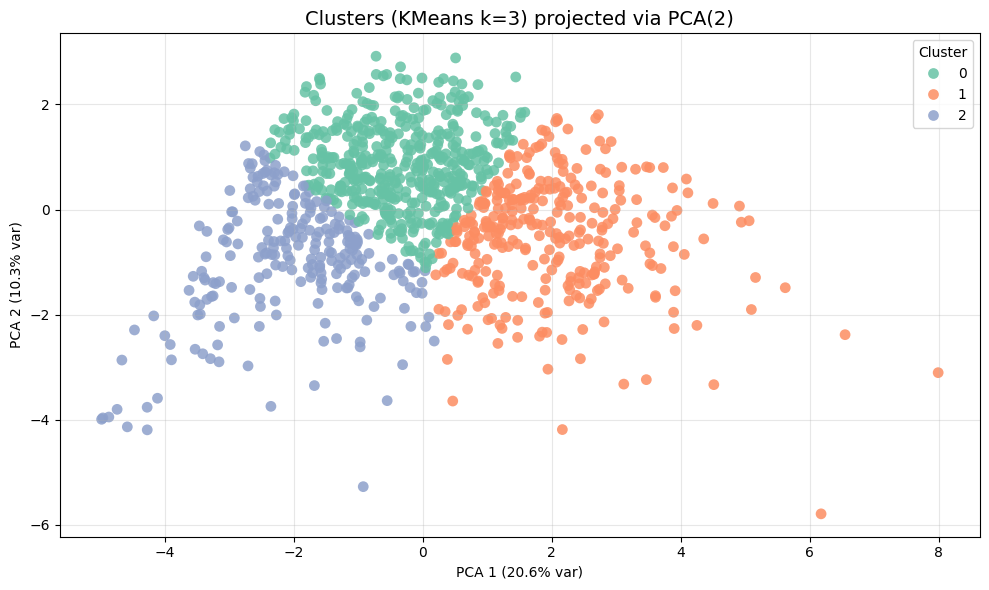

In [15]:
# ================================
# Steps 2–4: Preprocess → PCA(2) → KMeans(k=3) with one Pipeline
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# We work in unsupervised mode (no y)
X = df.copy()

# ---- 1) Identify feature types (Step 2: Prepare & Explore) ----
# If you have known categoricals, list them here; the code will only keep those that exist in X
forced_categoricals = [
    "gender", "age_group", "kids", "education", "net_income",
    "political_preference", "housing_status", "living_area"
]
categorical_features = [c for c in forced_categoricals if c in X.columns]
numeric_features = [c for c in X.columns if c not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features     :", numeric_features[:10], "..." if len(numeric_features) > 10 else "")

# ---- 2) Preprocessing: ColumnTransformer (impute → scale / encode) ----
# Note: if your data is already clean and complete, the imputers will just pass values through.
numeric_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ],
    remainder="drop"
)

# ---- 3) Full modeling pipeline: Preprocessing → PCA(2) → KMeans(k=3) ----
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("pca", PCA(n_components=2, random_state=42)),
    ("kmeans", KMeans(n_clusters=3, n_init="auto", random_state=42))
])

# Fit pipeline (Step 2 done; Step 3 & 4 in one go)
pipeline.fit(X)

# ---- 4) Get PCA projection & cluster labels for visualization ----
Xp = pipeline.named_steps["preprocessing"].transform(X)
X_pca = pipeline.named_steps["pca"].transform(Xp)
labels = pipeline.named_steps["kmeans"].labels_

# Optional: diagnostics
expl_var = pipeline.named_steps["pca"].explained_variance_ratio_
sil = silhouette_score(X_pca, labels)
print(f"PCA explained variance ratio: PC1={expl_var[0]:.3f}, PC2={expl_var[1]:.3f}")
print(f"Silhouette score (k=3, on PCA space): {sil:.3f}")

# ---- 5) Plot clusters in PCA space (clear 2D scatterplot) ----
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="Set2", s=60, alpha=0.85, edgecolor="none")
plt.title("Clusters (KMeans k=3) projected via PCA(2)", fontsize=14)
plt.xlabel(f"PCA 1 ({expl_var[0]*100:.1f}% var)")
plt.ylabel(f"PCA 2 ({expl_var[1]*100:.1f}% var)")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
